# Lesson 8: Design with Constraints

Lesson 7's designs searched over **every possible base** at every position
(`Domain("N13")`). Real designs almost always need to restrict that search:
embed a known functional motif, control GC content, guarantee that two
domains are complementary by construction rather than by luck, or forbid
sequence patterns that are hard to synthesize or sequence. This notebook
covers the main constraint tools: IUPAC wildcard alphabets, fixed domains,
complementary domains (`~domain`), `Pattern`, and `Diversity`.

**By the end of this notebook you will be able to:**

- Use IUPAC codes (`S`, `W`, `R`, `Y`, ...) to restrict a `Domain` to a subset
  of bases at each position.
- Mix fixed sequence, wildcard, and complementary domains within a single
  `TargetStrand`.
- Add `Pattern` and `Diversity` as `hard_constraints` to `tube_design` to
  exclude unwanted sequence features.
- Judge whether a constraint *helps* or *hurts* the achievable defect.

**Prerequisites:** [`07_intro_design.ipynb`](07_intro_design.ipynb)
(`Domain`, `TargetStrand`, `TargetComplex`, `tube_design`).


## Introduction

`Domain("N13")` told NUPACK "13 positions, each free to be A/C/G/U." Most real
design problems are more specific than that:

- *"This loop must be the sequence `GAAA`"* (a GNRA tetraloop - a
  well-studied, exceptionally stable RNA hairpin loop motif) - a **fixed**
  domain.
- *"This 5-nt stem must be G/C only"* (for a more thermally stable helix,
  recall lesson 6's salt/concentration $T_m$ dependence - GC pairs are
  stronger than AU/GU) - an **IUPAC-restricted** domain.
- *"This domain must be the complement of that domain"* - rather than relying
  on the optimizer to discover a complementary sequence from the target
  structure alone, declare it directly with `~domain`.
- *"Never put four identical bases in a row"* (synthesis/sequencing
  difficulty with homopolymer runs) - a `Pattern` hard constraint.

### Roadmap

1. **Fixed + complementary domains**: redo lesson 7's hairpin design with a
   fixed `GAAA` tetraloop and a stem built from `stem` / `~stem`, and compare
   defect to an unconstrained design of the same length.
2. **IUPAC alphabets**: compare a free (`N5`) stem to a GC-only (`S5`) stem -
   same defect, very different stability.
3. **`Pattern`**: show that unconstrained designs can contain homopolymer
   runs, and that a `Pattern` hard constraint reliably excludes them.


## Setup


In [1]:
from nupack import *

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import forgi.graph.bulge_graph as fgb
import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", palette="deep")

model = Model(material="rna", celsius=37, sodium=1.0)


def best_of(results):
    return min(results, key=lambda r: r.ensemble_defect)


def plot_structure(sequence, structure, ax, title):
    bg = fgb.BulgeGraph.from_dotbracket(structure, seq=sequence)
    fvm.plot_rna(bg, ax=ax, lighten=0.7, text_kwargs={"fontweight": "black"})
    ax.set_title(title)


## Theory: constraining the search space

**IUPAC wildcard alphabets.** `Domain("N13")` uses `N` (any of A/C/G/U) at
every position, but any IUPAC nucleotide code is allowed per-position:

| Code | Allowed bases   | Meaning            |
|------|-----------------|--------------------|
| `N`  | A, C, G, U      | any                |
| `S`  | G, C            | "strong" pair (GC) |
| `W`  | A, U            | "weak" pair (AU)   |
| `R`  | A, G            | purine             |
| `Y`  | C, U            | pyrimidine         |
| `K`  | G, U            | keto               |
| `M`  | A, C            | amino              |

`Domain("S5")` means "5 positions, each restricted to G or C" - the optimizer
can still choose *which* G/C at each position, just not A/U.

**Fixed domains.** A `Domain` string with no wildcard characters at all
(e.g. `Domain("GAAA")`) is **fixed** - the optimizer treats it as a literal
constant. This is how you embed a known motif (a tetraloop, a
protein-binding site, a restriction site you *want*) into a design.

**Complementary domains.** `~domain` (Python's `~` operator on a `Domain`)
returns a new `Domain` object that is constrained to be the reverse
complement of `domain`, wherever it's the same length. Using `stem` and
`~stem` as two parts of a `TargetStrand` (e.g. for a hairpin stem) guarantees
they pair correctly *by construction* - the target structure's `(((...)))`
pairing and the domains' complementarity now say the same thing redundantly,
which actually helps the optimizer (less to discover).

**`Pattern(patterns, scope=None, weight=1)`** added to `hard_constraints`
forbids the listed subsequences from appearing anywhere in `scope` (or
globally if `scope=None`). **`Diversity(word, types, scope=None)`** requires
at least `types` distinct nucleotide types within every window of `word`
consecutive positions - another way to avoid repetitive runs.


## Worked example 1: a GNRA-tetraloop hairpin

GNRA tetraloops (`G`, any base, purine, `A`) are among the most stable and
well-characterized RNA hairpin loops. We compare two 14-nt hairpin designs
targeting `(((((....)))))`:

1. **Unconstrained**: `Domain("N14")` - lesson 7's approach, scaled to 14 nt.
2. **GNRA-constrained**: a 5-nt wildcard `stem` domain, a fixed `GAAA` loop,
   and `~stem` to close the hairpin - guaranteeing a real stem *and* a known
   stable loop.


In [2]:
target_hairpin = "(((((....)))))"

# 1. Unconstrained
d_full = Domain("N14", name="d_full")
strand_full = TargetStrand([d_full], name="s_full")
c_full = TargetComplex([strand_full], target_hairpin, name="c_full")
t_full = TargetTube(on_targets={c_full: 1e-6}, name="t_full")
results_full = tube_design(tubes=[t_full], model=model).run(trials=5)
best_full = best_of(results_full)
seq_full = str(best_full.domains[d_full])

# 2. GNRA-constrained
stem = Domain("N5", name="stem")
loop = Domain("GAAA", name="loop")
strand_gnra = TargetStrand([stem, loop, ~stem], name="s_gnra")
c_gnra = TargetComplex([strand_gnra], target_hairpin, name="c_gnra")
t_gnra = TargetTube(on_targets={c_gnra: 1e-6}, name="t_gnra")
results_gnra = tube_design(tubes=[t_gnra], model=model).run(trials=5)
best_gnra = best_of(results_gnra)
seq_gnra = str(best_gnra.domains[stem]) + str(best_gnra.domains[loop]) + str(best_gnra.domains[~stem])

defect_table = pd.DataFrame(
    {
        "design": ["unconstrained N14", "GNRA tetraloop (stem + GAAA + ~stem)"],
        "sequence": [seq_full, seq_gnra],
        "best ensemble defect": [best_full.ensemble_defect, best_gnra.ensemble_defect],
    }
)
display(defect_table)


,design,sequence,best ensemble defect
0,unconstrained N14,GGUCCAAGAGGGCC,0.007894
1,GNRA tetraloop (stem + GAAA + ~stem),GCACCGAAAGGUGC,0.006022


findfont: Failed to find font weight black, now using 700.


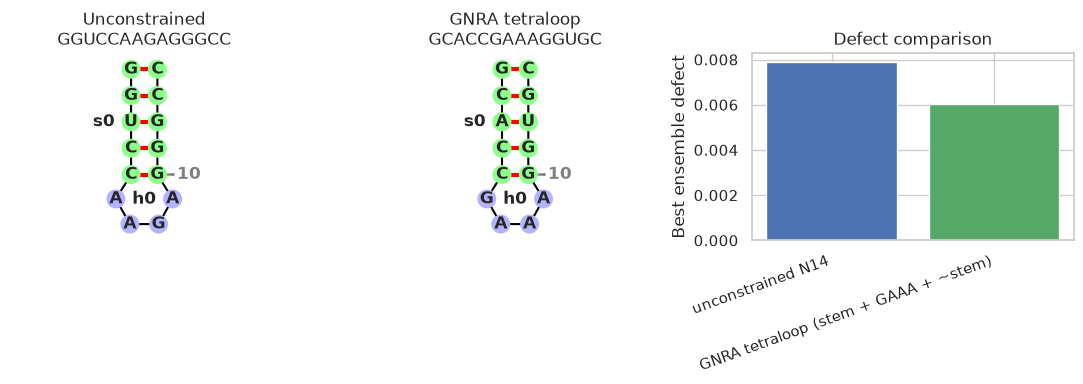

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1, 1.2]})

plot_structure(seq_full, target_hairpin, axes[0], f"Unconstrained\n{seq_full}")
plot_structure(seq_gnra, target_hairpin, axes[1], f"GNRA tetraloop\n{seq_gnra}")

axes[2].bar(defect_table["design"], defect_table["best ensemble defect"], color=["#4c72b0", "#55a868"])
axes[2].set_ylabel("Best ensemble defect")
axes[2].set_title("Defect comparison")
plt.setp(axes[2].get_xticklabels(), rotation=20, ha="right")

fig.tight_layout()
plt.show()


**Interpretation.** Both designs reach low defect, but the GNRA-constrained
design typically does *at least* as well as the unconstrained one - despite
searching a much smaller space (the loop is fixed, and the stem is forced
complementary). **Constraints don't always cost you defect**: `GAAA` is a
loop sequence that is *known* to fold cleanly, so fixing it removes a part of
the search the optimizer would otherwise have to "discover" on its own, and
`~stem` removes the (easy, but still nonzero) work of finding complementary
bases for a structure that already specifies pairing.


## Worked example 2: controlling GC content with IUPAC codes

Keep the `GAAA` tetraloop and `~stem` complementarity from worked example 1,
but compare a free `N5` stem to a GC-only `S5` stem. Both target the same
structure; we compare defect *and* the resulting structure's free energy
(recall from lesson 6: more stable helices have higher $T_m$).


In [4]:
loop = Domain("GAAA", name="loop")

def design_stem(stem_pattern, name):
    stem = Domain(stem_pattern, name=f"stem_{name}")
    strand = TargetStrand([stem, loop, ~stem], name=f"s_{name}")
    c = TargetComplex([strand], target_hairpin, name=f"c_{name}")
    t = TargetTube(on_targets={c: 1e-6}, name=f"t_{name}")
    results = tube_design(tubes=[t], model=model).run(trials=5)
    best = best_of(results)
    seq = str(best.domains[stem]) + str(best.domains[loop]) + str(best.domains[~stem])
    energy = structure_energy(strands=[seq], structure=target_hairpin, model=model)
    return best.ensemble_defect, seq, energy

defect_n, seq_n, energy_n = design_stem("N5", "n")
defect_s, seq_s, energy_s = design_stem("S5", "s")

stem_table = pd.DataFrame(
    {
        "stem alphabet": ["N5 (any base)", "S5 (G/C only)"],
        "sequence": [seq_n, seq_s],
        "best ensemble defect": [defect_n, defect_s],
        "G(target) [kcal/mol]": [energy_n, energy_s],
    }
)
display(stem_table)


,stem alphabet,sequence,best ensemble defect,G(target) [kcal/mol]
0,N5 (any base),GGUGGGAAACCACC,0.007743,-7.8
1,S5 (G/C only),GGCCCGAAAGGGCC,0.007093,-10.0


**Interpretation.** Both stems reach comparably low defect - `defect(...)`
measures how well the structure matches the *ensemble for this sequence*,
which an `S5` stem can satisfy just as well as an `N5` stem. But the free
energies differ substantially: the all-GC stem is several kcal/mol more
stable (more negative $G$). Per lesson 6, a more stable helix has a higher
$T_m$ - so the `S5` constraint is a simple way to bias a design toward
higher thermal stability *without* changing the target structure or the
defect objective at all.


## Worked example 3: forbidding homopolymer runs with `Pattern`

A 20-nt unstructured domain (`Domain("N20")`, target `"." * 20`) has nothing
to constrain its sequence beyond "be 20 nt long" - across enough trials,
homopolymer runs (e.g. `AAAA`) can appear. Add `Pattern(["AAAA", "CCCC",
"GGGG", "UUUU"])` as a hard constraint and check that they no longer do.


In [5]:
target_unstructured = "." * 20

def count_runs(seq, length=4):
    return len(re.findall(r"(.)\1{" + str(length - 1) + r",}", seq))

d20 = Domain("N20", name="d20")
strand20 = TargetStrand([d20], name="s20")
c20 = TargetComplex([strand20], target_unstructured, name="c20")
t20 = TargetTube(on_targets={c20: 1e-6}, name="t20")

results_unconstrained = tube_design(tubes=[t20], model=model).run(trials=8)
seqs_unconstrained = [str(r.domains[d20]) for r in results_unconstrained]

pattern_constraint = Pattern(["AAAA", "CCCC", "GGGG", "UUUU"])
results_constrained = tube_design(
    tubes=[t20], model=model, hard_constraints=[pattern_constraint]
).run(trials=8)
seqs_constrained = [str(r.domains[d20]) for r in results_constrained]

pattern_table = pd.DataFrame(
    {
        "trial": range(8),
        "unconstrained": seqs_unconstrained,
        "runs (unconstrained)": [count_runs(s) for s in seqs_unconstrained],
        "Pattern-constrained": seqs_constrained,
        "runs (constrained)": [count_runs(s) for s in seqs_constrained],
    }
)
display(pattern_table)
print("total runs, unconstrained:", pattern_table["runs (unconstrained)"].sum())
print("total runs, constrained:  ", pattern_table["runs (constrained)"].sum())


,trial,unconstrained,runs (unconstrained),Pattern-constrained,runs (constrained)
0,0,CCGACACUACACCCAUUCAG,0,AAAGUGGGAUGAGGAGAAAG,0
1,1,CAUAACCUCCAGACACGCCU,0,CAUCCCACGCGUCAAUAAUA,0
2,2,UAACCUUUGCUAUACUUUGA,0,AAAUACCUAUCAUUCUCUUC,0
3,3,GUCUUUUUCCCUCGUACUAG,1,UUCAACCUGCCAUAUACACU,0
4,4,UAAAAUCAGCAGCGUCCCAG,1,AUAGUUUAUUUCGGUCGUUU,0
5,5,AGAUCAACAACCAACCCCAU,1,CCCUGCAACUUAAUAAUUAU,0
6,6,UUUGUUAUUGUAGUUUUUCC,1,GGGAAGAUAGGGAGGUGGGC,0
7,7,UCUCAUAUAAACGCACAUUU,0,ACUAAACUCGCCAAUUCUUG,0


total runs, unconstrained: 4
total runs, constrained:   0


**Interpretation.** Across 8 unconstrained trials, one or more sequences may
contain a run of 4+ identical bases - nothing in the defect objective
penalizes them (a homopolymer run can still fold "correctly" into an
unstructured target). With the `Pattern` hard constraint, **every** trial's
sequence is guaranteed free of these runs, by construction - not just "on
average" or "usually."


## Best practices and common pitfalls

- **Fixed/complementary domains aren't "free" if poorly chosen.** Fixing a
  loop sequence helps when that sequence is *known* to be compatible with the
  target structure (like `GAAA` for a 4-nt hairpin loop) - fixing an
  arbitrary or incompatible sequence can only hurt the achievable defect,
  never help.
- **`~domain` only enforces complementarity, not energetics.** It guarantees
  `stem` and `~stem` are Watson-Crick complements; whether that helix is
  *also* the MFE structure still depends on the rest of the sequence
  (competing structures elsewhere) - `~domain` is necessary but not
  sufficient for a clean hairpin.
- **IUPAC restrictions can make a target structure unreachable.** E.g. an
  all-`W` (`A`/`U`-only) stem for a long helix may simply not be stable enough
  for the target structure to be the MFE at all, no matter what the optimizer
  picks - check the resulting `ensemble_defect`, don't assume the constraint
  is "compatible" just because the design ran without error.
- **`Pattern`/`Diversity` apply globally by default.** Use `scope=[...]` to
  restrict a pattern constraint to specific domains if you only want to
  forbid a motif in *part* of a multi-domain strand (e.g. allow a fixed motif
  that itself contains a homopolymer run, while forbidding runs elsewhere).


## Summary

In this notebook you:

1. Used **IUPAC wildcard codes** (`S5` for a GC-only stem) to restrict
   `Domain` alphabets without changing the design objective.
2. Combined **fixed domains** (`GAAA`) with **complementary domains**
   (`~stem`) to embed a known-stable motif and guarantee correct stem
   pairing by construction - and saw this can *improve* defect, not just
   restrict it.
3. Used **`Pattern`** as a hard constraint to reliably exclude homopolymer
   runs that an unconstrained search can otherwise produce.

**Next:** [`09_tube_design.ipynb`](09_tube_design.ipynb) designs **multiple
complexes in one tube at once** - including off-targets - to address
orthogonality: making sure designed sequences don't just fold correctly on
their own, but also don't cross-react with each other.


## Exercises

1. Try a `W5` (A/U-only) stem in worked example 2's `design_stem` function.
   How does its `ensemble_defect` and $G(\text{target})$ compare to the `N5`
   and `S5` stems? Is the 5-bp `(((((....)))))` structure still achievable?
2. Use `Diversity(word=3, types=3)` as a hard constraint on the 20-nt
   unstructured domain from worked example 3. How does it compare to the
   `Pattern`-based approach at excluding homopolymer runs - does it forbid
   anything `Pattern` doesn't, or vice versa?
